# 통근시간 외적 타당도 검증

이 노트북은 2025년 서울→서울 **출근 목적 OD 데이터**에서 계산한 평균 이동시간과
동일한 출발·도착 행정동의 **카카오맵 대중교통 경로 API 시간**을 비교한다.

검증 질문은 다음과 같다.

> OD 이동시간이 외부 경로 API 시간과 지역 간 순서와 시간 수준에서 일관되는가?

검증 결과가 일관되면 OD 데이터는 주요 통근 목적지와 이동비중을 계산하는 자료로,
경로 API 시간은 대표 통근시간을 계산하는 외부 시간 자료로 연결할 수 있다.

이 노트북은 원본 CSV를 수정하지 않는다. 계산 결과와 API 캐시만 결과 폴더에 새로 저장한다.

## 1. 검증 기준과 핵심 산식

### OD 평균 이동시간

```text
OD 평균 이동시간
= Σ(이동 시간 × 이동 인구수) ÷ Σ(이동 인구수)
```

### 목적지 이동비중

```text
목적지 이동비중
= 해당 OD 출근 이동량 ÷ 출발 행정동 전체 출근 이동량
```

주 분석은 누적 목적지 비중 80%를 사용하고 70%와 90%를 함께 비교한다.

### API 경로 포함률

```text
API 외부경로 포함률
= API 조회 성공 외부 OD 출근량 ÷ 선택된 외부 OD 전체 출근량 × 100
```

### 외적 타당성 판단 자료

- Spearman·Kendall 순위상관계수
- 평균 절대오차(MAE)
- 통행량 가중 평균 절대오차
- 통행량 가중 편향
- API 장시간·단시간 집단의 OD 시간 차이
- 누적 목적지 비중 70%·80%·90% 민감도

출발동과 도착동이 같은 내부 통근은 API 비교에서 제외한다.
최종 대표 통근시간을 만들 때만 원본 OD 내부 평균시간을 사용한다.

In [44]:
import os
import requests
from getpass import getpass

# 기존 환경변수에 저장된 이전 키가 사용되지 않도록 제거
os.environ.pop("KAKAO_REST_API_KEY", None)

# 현재 앱의 REST API 키를 다시 입력
KAKAO_KEY = getpass(
    "현재 앱의 REST API 키 입력: "
).strip()

# 주민센터 한 곳만 시험
response = requests.get(
    "https://dapi.kakao.com/v2/local/search/keyword.json",
    headers={
        "Authorization": f"KakaoAK {KAKAO_KEY}"
    },
    params={
        "query": "서울특별시 종로구 청운효자동 주민센터",
        "size": 1
    },
    timeout=20
)

print("응답 상태:", response.status_code)
print(response.text[:500])

응답 상태: 200
{"documents":[{"address_name":"서울 종로구 궁정동 12-1","category_group_code":"PO3","category_group_name":"공공기관","category_name":"사회,공공기관 \u003e 지방행정기관 \u003e 행정복지센터 \u003e 동행정복지센터","distance":"","id":"15426945","phone":"02-2148-5001","place_name":"청운효자동주민센터","place_url":"http://place.map.kakao.com/15426945","road_address_name":"서울 종로구 자하문로 92","x":"126.97064969123","y":"37.5841161738413"}],"meta":{"is_end":false,"pageable_count":4,"same_name":{"keyword":"청운효자동 주민센터","region":[],"selected_region":"서울 종로


## 2. 라이브러리와 실행 경로

로컬에서는 현재 프로젝트 경로를 그대로 사용한다.
Google Colab에서는 `COLAB_PROJECT_DIR` 한 줄만 실제 드라이브 위치로 수정한다.

In [45]:
from pathlib import Path
from getpass import getpass
from datetime import datetime
import json
import os
import time

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau, mannwhitneyu

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)

# 코랩인지 확인
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")

    # 본인의 Google Drive 폴더 위치에 맞게 이 한 줄만 수정한다.
    COLAB_PROJECT_DIR = Path(
        "/content/drive/MyDrive/MULTICAM_11/프로젝트 전처리"
    )
    PROJECT_DIR = COLAB_PROJECT_DIR
else:
    PROJECT_DIR = Path(
        r"C:\Users\Owner\OneDrive\바탕 화면\데이터 분석"
        r"\MULTICAM_11\프로젝트 전처리"
    )

DATA_DIR = PROJECT_DIR / "OD 데이터 (이동수간 전처리)"
RESULT_DIR = PROJECT_DIR / "통근 시간 외적 타당도 검증"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

OD_CACHE_FILE = RESULT_DIR / "2025년_출근_OD_집계.csv"
COORD_CACHE_FILE = RESULT_DIR / "행정동_주민센터_좌표_캐시.csv"
ROUTE_CACHE_FILE = RESULT_DIR / "OD_API_경로조회결과.csv"

print("데이터 폴더:", DATA_DIR)
print("결과 폴더:", RESULT_DIR)

데이터 폴더: C:\Users\Owner\OneDrive\바탕 화면\데이터 분석\MULTICAM_11\프로젝트 전처리\OD 데이터 (이동수간 전처리)
결과 폴더: C:\Users\Owner\OneDrive\바탕 화면\데이터 분석\MULTICAM_11\프로젝트 전처리\통근 시간 외적 타당도 검증


## 3. 실행 설정

처음에는 `RUN_API = True`, `TEST_ONLY = True`로 5개 OD만 시험한다.
시험 결과가 정상이라면 `TEST_ONLY = False`로 바꾸어 전체 API 조회를 이어서 실행한다.

대중교통 경로 API는 무료 한도를 넘지 않도록 하루 최대 900건만 호출한다.
같은 날 다시 실행하면 캐시의 조회시각을 확인하여 남은 호출 수만 실행한다.

성공 결과와 정상적인 `NO_RESULTS`는 완료 처리하고, HTTP 오류는 다음 실행에서 다시 조회한다.
HTTP 오류가 3회 연속 발생하면 불필요한 반복 호출을 막기 위해 자동으로 중단한다.

API 키는 입력창으로만 받고 파일에 저장하거나 화면에 출력하지 않는다.


In [ ]:
REBUILD_OD = False
RUN_API = True
TEST_ONLY = False
TEST_LIMIT = 5

CHUNK_SIZE = 200_000
API_SLEEP_SECONDS = 0.15

# 대중교통 경로 API의 무료 일일 한도는 1,000건이다.
# 시험 호출과 수동 확인을 고려하여 하루 최대 900건만 호출한다.
DAILY_ROUTE_LIMIT = 900
MAX_CONSECUTIVE_API_ERRORS = 3
CACHE_SAVE_EVERY = 20

MAIN_THRESHOLD = 0.80
SENSITIVITY_THRESHOLDS = [0.70, 0.80, 0.90]

KAKAO_KEY = (
    getpass(
        "현재 앱의 REST API 키 입력: "
    ).strip()
    if RUN_API
    else ""
)

print("API 실행 여부:", RUN_API)
print("시험 조회 여부:", TEST_ONLY)
print("일일 최대 경로 호출:", DAILY_ROUTE_LIMIT)


In [47]:
# 실패한 API 캐시를 초기화할 때만 True
RESET_API_CACHE = False

if RESET_API_CACHE:

    for cache_file in [
        COORD_CACHE_FILE,
        ROUTE_CACHE_FILE
    ]:
        if cache_file.exists():
            cache_file.unlink()
            print("삭제:", cache_file.name)

    print("API 캐시 초기화 완료")

## 4. 입력 파일과 컬럼 확인

월별 파일이 모두 있는지 확인하고 첫 번째 파일의 헤더만 읽는다.
대용량 파일 전체를 이 단계에서 메모리에 올리지 않는다.

In [48]:
def month_number(file_path):
    return int(file_path.name.split("월")[0])


monthly_files = sorted(
    DATA_DIR.glob("*월 이동 데이터 전연령 통합.csv"),
    key=month_number
)

print("찾은 월별 파일 수:", len(monthly_files))
for file in monthly_files:
    print(f"- {file.name}: {file.stat().st_size / 1024**3:.2f} GB")

if len(monthly_files) != 12:
    raise FileNotFoundError(
        "1~12월 월별 CSV 12개를 모두 찾지 못했습니다. DATA_DIR을 확인하세요."
    )


COLUMN_ALIASES = {
    "o_admdong_cd": "출발 행정동 코드",
    "d_admdong_cd": "도착 행정동 코드",
    "st_time_cd": "출발 시간 코드",
    "fns_time_cd": "도착 시간 코드",
    "move_purpose": "이동 목적 코드",
    "move_dist": "이동거리",
    "move_time": "이동 시간",
    "cnt": "이동 인구수",
    "etl_ymd": "데이터 기준일"
}

REQUIRED_COLUMNS = [
    "출발 행정동 코드",
    "도착 행정동 코드",
    "이동 목적 코드",
    "이동거리",
    "이동 시간",
    "이동 인구수"
]


def find_encoding(file_path):
    for encoding in ["utf-8-sig", "cp949", "utf-8"]:
        try:
            pd.read_csv(file_path, encoding=encoding, nrows=2)
            return encoding
        except UnicodeDecodeError:
            continue

    raise UnicodeDecodeError(
        "csv", b"", 0, 1,
        f"{file_path.name}의 인코딩을 확인하지 못했습니다."
    )


def read_csv_safely(file_path, **read_options):
    encoding = find_encoding(file_path)
    return pd.read_csv(
        file_path,
        encoding=encoding,
        **read_options
    )


sample_encoding = find_encoding(monthly_files[0])
sample_columns = read_csv_safely(
    monthly_files[0],
    nrows=0
).columns.tolist()

normalized_sample_columns = [
    COLUMN_ALIASES.get(column, column)
    for column in sample_columns
]

print("첫 파일 인코딩:", sample_encoding)
print("첫 파일 컬럼:", normalized_sample_columns)

missing_columns = [
    column for column in REQUIRED_COLUMNS
    if column not in normalized_sample_columns
]

if missing_columns:
    raise KeyError(f"필수 컬럼이 없습니다: {missing_columns}")

찾은 월별 파일 수: 12
- 1월 이동 데이터 전연령 통합.csv: 3.77 GB
- 2월 이동 데이터 전연령 통합.csv: 3.69 GB
- 3월 이동 데이터 전연령 통합.csv: 3.96 GB
- 4월 이동 데이터 전연령 통합.csv: 4.28 GB
- 5월 이동 데이터 전연령 통합.csv: 4.23 GB
- 6월 이동 데이터 전연령 통합.csv: 4.09 GB
- 7월 이동 데이터 전연령 통합.csv: 4.45 GB
- 8월 이동 데이터 전연령 통합.csv: 4.02 GB
- 9월 이동 데이터 전연령 통합.csv: 4.43 GB
- 10월 이동 데이터 전연령 통합.csv: 4.23 GB
- 11월 이동 데이터 전연령 통합.csv: 4.01 GB
- 12월 이동 데이터 전연령 통합.csv: 4.46 GB
첫 파일 인코딩: utf-8-sig
첫 파일 컬럼: ['출발 행정동 코드', '출발 행정동', '도착 행정동 코드', '도착 행정동', '출발 시간 코드', '도착 시간 코드', '이동 목적 코드', '이동거리', '이동 시간', '이동 인구수', '데이터 기준일', '요일']


## 5. 행정동 코드와 출근 OD 집계 함수

2025년 연간 분석에서는 다음 코드를 분석용 용신동 코드로 통일한다.

```text
신설동 11230515 → 용신동 11230536
용두동 11230533 → 용신동 11230536
```

월별 CSV는 20만 행씩 읽고 출근 목적 코드 1만 남긴다.

In [49]:
ANNUAL_CODE_MAP = {
    "11230515": "11230536",
    "11230533": "11230536"
}


def clean_code(series):
    digits = (
        series.astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.replace(r"[^0-9]", "", regex=True)
    )
    cleaned = digits.str.zfill(8)
    valid = digits.str.len().between(1, 8)
    return cleaned.where(valid)


def harmonize_annual_codes(data):
    result = data.copy()
    for column in ["출발 행정동 코드", "도착 행정동 코드"]:
        result[column] = clean_code(result[column])
        result[column] = result[column].replace(ANNUAL_CODE_MAP)
    return result


def aggregate_month_file(file_path, chunksize=200_000):
    encoding = find_encoding(file_path)
    header = pd.read_csv(
        file_path,
        encoding=encoding,
        nrows=0
    ).columns.tolist()

    use_columns = [
        column for column in header
        if COLUMN_ALIASES.get(column, column) in REQUIRED_COLUMNS
    ]

    parts = []
    total_rows = 0
    commute_rows = 0
    invalid_rows = 0

    reader = pd.read_csv(
        file_path,
        encoding=encoding,
        usecols=use_columns,
        chunksize=chunksize,
        low_memory=False
    )

    for chunk in reader:
        total_rows += len(chunk)
        chunk = chunk.rename(columns=COLUMN_ALIASES)

        purpose = pd.to_numeric(
            chunk["이동 목적 코드"],
            errors="coerce"
        )
        chunk = chunk[purpose.eq(1)].copy()
        commute_rows += len(chunk)

        if chunk.empty:
            continue

        chunk = harmonize_annual_codes(chunk)
        chunk["이동거리"] = pd.to_numeric(
            chunk["이동거리"], errors="coerce"
        )
        chunk["이동 시간"] = pd.to_numeric(
            chunk["이동 시간"], errors="coerce"
        )
        chunk["이동 인구수"] = pd.to_numeric(
            chunk["이동 인구수"], errors="coerce"
        )

        valid = (
            chunk["출발 행정동 코드"].notna()
            & chunk["도착 행정동 코드"].notna()
            & chunk["이동거리"].ge(0)
            & chunk["이동 시간"].ge(0)
            & chunk["이동 인구수"].gt(0)
        )

        invalid_rows += int((~valid).sum())
        chunk = chunk[valid].copy()

        chunk["시간가중합"] = (
            chunk["이동 시간"] * chunk["이동 인구수"]
        )
        chunk["거리가중합"] = (
            chunk["이동거리"] * chunk["이동 인구수"]
        )

        grouped = (
            chunk.groupby(
                ["출발 행정동 코드", "도착 행정동 코드"],
                as_index=False
            )[["이동 인구수", "시간가중합", "거리가중합"]]
            .sum()
        )
        parts.append(grouped)

    if not parts:
        raise ValueError(f"{file_path.name}에서 출근 목적 행을 찾지 못했습니다.")

    monthly = pd.concat(parts, ignore_index=True)
    monthly = (
        monthly.groupby(
            ["출발 행정동 코드", "도착 행정동 코드"],
            as_index=False
        )[["이동 인구수", "시간가중합", "거리가중합"]]
        .sum()
    )

    quality = {
        "파일명": file_path.name,
        "전체 행": total_rows,
        "출근 목적 행": commute_rows,
        "계산 제외 행": invalid_rows
    }
    return monthly, quality


def aggregate_commute_od(files, chunksize=200_000):
    monthly_parts = []
    quality_rows = []

    for file_path in files:
        print("집계 중:", file_path.name)
        monthly, quality = aggregate_month_file(
            file_path,
            chunksize=chunksize
        )
        monthly_parts.append(monthly)
        quality_rows.append(quality)

    annual = pd.concat(monthly_parts, ignore_index=True)
    annual = (
        annual.groupby(
            ["출발 행정동 코드", "도착 행정동 코드"],
            as_index=False
        )[["이동 인구수", "시간가중합", "거리가중합"]]
        .sum()
    )

    annual["OD 평균 이동시간(분)"] = (
        annual["시간가중합"] / annual["이동 인구수"]
    )
    annual["OD 평균 이동거리(m)"] = (
        annual["거리가중합"] / annual["이동 인구수"]
    )

    annual = annual.drop(
        columns=["시간가중합", "거리가중합"]
    )

    return annual, pd.DataFrame(quality_rows)

## 6. 2025년 출근 OD 집계 실행

In [50]:
if OD_CACHE_FILE.exists() and not REBUILD_OD:
    commute_od = pd.read_csv(
        OD_CACHE_FILE,
        encoding="utf-8-sig",
        dtype={
            "출발 행정동 코드": "string",
            "도착 행정동 코드": "string"
        }
    )
    quality_result = pd.DataFrame()
    print("기존 OD 집계 캐시를 읽었습니다.")
else:
    commute_od, quality_result = aggregate_commute_od(
        monthly_files,
        chunksize=CHUNK_SIZE
    )
    commute_od.to_csv(
        OD_CACHE_FILE,
        index=False,
        encoding="utf-8-sig"
    )
    print("OD 집계 캐시를 생성했습니다.")

print("집계된 OD 수:", f"{len(commute_od):,}")
print("출발 행정동 수:", commute_od["출발 행정동 코드"].nunique())
print("도착 행정동 수:", commute_od["도착 행정동 코드"].nunique())

if not quality_result.empty:
    display(quality_result)

display(commute_od.head(10))

기존 OD 집계 캐시를 읽었습니다.
집계된 OD 수: 175,509
출발 행정동 수: 426
도착 행정동 수: 426


,출발 행정동 코드,도착 행정동 코드,이동 인구수,OD 평균 이동시간(분),OD 평균 이동거리(m)
0,11110515,11110515,94324.670,14.528,471.490
1,11110515,11110530,98963.430,16.724,867.719
2,11110515,11110540,14240.180,19.503,1235.064
3,11110515,11110550,9291.320,15.736,1719.977
4,11110515,11110560,7100.510,22.367,2914.699
5,11110515,11110570,3388.880,17.495,1077.958
6,11110515,11110580,6452.970,29.362,1327.347
7,11110515,11110600,16070.820,22.560,1732.590
8,11110515,11110615,78199.850,25.340,1734.285
9,11110515,11110630,6460.270,40.507,3391.777


## 7. 누적 목적지 비중 계산

각 출발 행정동에서 이동량이 많은 목적지부터 정렬한다.
기준을 처음 넘어서는 목적지까지 포함하여 누적 70%·80%·90% 자료를 만든다.

In [51]:
def select_destinations(od_data, threshold=0.80):
    selected_parts = []

    for origin_code, group in od_data.groupby("출발 행정동 코드"):
        group = group.sort_values(
            "이동 인구수",
            ascending=False
        ).copy()

        total_flow = group["이동 인구수"].sum()
        group["목적지 이동비중"] = group["이동 인구수"] / total_flow
        group["누적 목적지 비중"] = group["목적지 이동비중"].cumsum()
        group["이전 누적비중"] = (
            group["누적 목적지 비중"] - group["목적지 이동비중"]
        )

        selected = group[group["이전 누적비중"] < threshold].copy()
        selected["선택 기준"] = threshold
        selected_parts.append(selected)

    return pd.concat(selected_parts, ignore_index=True)


selected_80 = select_destinations(commute_od, MAIN_THRESHOLD)
selected_90 = select_destinations(
    commute_od,
    max(SENSITIVITY_THRESHOLDS)
)

selected_80.to_csv(
    RESULT_DIR / "누적80퍼센트_주요출근OD.csv",
    index=False,
    encoding="utf-8-sig"
)

print("누적 80% 선택 OD:", f"{len(selected_80):,}")
print("API 준비용 누적 90% OD:", f"{len(selected_90):,}")
display(selected_80.head(10))

누적 80% 선택 OD: 29,151
API 준비용 누적 90% OD: 50,510


,출발 행정동 코드,도착 행정동 코드,이동 인구수,OD 평균 이동시간(분),OD 평균 이동거리(m),목적지 이동비중,누적 목적지 비중,이전 누적비중,선택 기준
0,11110515,11110530,98963.430,16.724,867.719,0.116,0.116,0.000,0.800
1,11110515,11110515,94324.670,14.528,471.490,0.111,0.227,0.116,0.800
2,11110515,11110615,78199.850,25.340,1734.285,0.092,0.319,0.227,0.800
3,11110515,11140550,30883.930,29.712,2216.816,0.036,0.355,0.319,0.800
4,11110515,11140520,23399.420,28.256,2118.882,0.028,0.383,0.355,0.800
5,11110515,11560540,20404.770,40.786,7395.349,0.024,0.407,0.383,0.800
6,11110515,11140540,16930.380,32.200,2765.094,0.020,0.427,0.407,0.800
7,11110515,11110600,16070.820,22.560,1732.590,0.019,0.446,0.427,0.800
8,11110515,11680640,15159.400,57.458,10848.063,0.018,0.464,0.446,0.800
9,11110515,11110540,14240.180,19.503,1235.064,0.017,0.480,0.464,0.800


## 8. 행정동 코드표와 주민센터 좌표 준비

구·신 행정동 코드표를 함께 읽고 문자열을 정리한다.
API 조회 대상은 누적 90% OD에 포함된 출발·도착 행정동이다.

In [52]:
def find_reference_file(file_name):
    candidates = [
        DATA_DIR / file_name,
        RESULT_DIR / file_name,
        PROJECT_DIR / file_name
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    matches = list(PROJECT_DIR.rglob(file_name))
    if matches:
        return matches[0]

    raise FileNotFoundError(f"행정동 코드표를 찾지 못했습니다: {file_name}")


def read_admdong_reference():
    old_file = find_reference_file(
        "seoul_admi_list_2023_to_202507.csv"
    )
    new_file = find_reference_file(
        "seoul_admi_list_202508_to_202606.csv"
    )

    references = []
    for file_path, code_period in [
        (old_file, "2023~2025.07"),
        (new_file, "2025.08~2026.06")
    ]:
        reference = pd.read_csv(
            file_path,
            encoding="utf-8-sig",
            dtype={
                "자치구": "string",
                "행정동코드": "string",
                "행정동명": "string"
            }
        )
        reference["코드기준"] = code_period
        references.append(reference)

    result = pd.concat(references, ignore_index=True)

    for column in ["자치구", "행정동명"]:
        result[column] = result[column].astype("string").str.strip()

    result["행정동코드"] = clean_code(result["행정동코드"])
    result = (
        result.dropna(subset=["행정동코드"])
        .drop_duplicates(subset=["행정동코드"], keep="last")
        .sort_values("행정동코드")
        .reset_index(drop=True)
    )
    return result


admdong_ref = read_admdong_reference()

target_codes = pd.unique(
    pd.concat([
        selected_90["출발 행정동 코드"],
        selected_90["도착 행정동 코드"]
    ], ignore_index=True)
)

coordinate_targets = admdong_ref[
    admdong_ref["행정동코드"].isin(target_codes)
][["행정동코드", "자치구", "행정동명"]].copy()

missing_reference_codes = sorted(
    set(target_codes) - set(coordinate_targets["행정동코드"])
)

print("좌표 검색 대상 행정동:", len(coordinate_targets))
print("코드표 미매핑 행정동:", len(missing_reference_codes))

if missing_reference_codes:
    display(pd.DataFrame({"코드표 미매핑 행정동": missing_reference_codes}))

display(coordinate_targets.head(10))

좌표 검색 대상 행정동: 426
코드표 미매핑 행정동: 0


,행정동코드,자치구,행정동명
0,11110515,종로구,청운효자동
1,11110530,종로구,사직동
2,11110540,종로구,삼청동
3,11110550,종로구,부암동
4,11110560,종로구,평창동
5,11110570,종로구,무악동
6,11110580,종로구,교남동
7,11110600,종로구,가회동
8,11110615,종로구,종로1.2.3.4가동
9,11110630,종로구,종로5.6가동


## 9. 카카오 주민센터 좌표 검색 함수

검색어는 `서울특별시 + 자치구 + 행정동명 + 주민센터`로 구성한다.
검색 결과 주소에 해당 자치구가 들어 있는 결과를 우선 사용한다.

In [53]:
KAKAO_KEYWORD_URL = (
    "https://dapi.kakao.com/v2/local/search/keyword.json"
)
KAKAO_PUBLIC_TRANSIT_URL = (
    "https://dapi.kakao.com/v2/routing/publictraffic"
)

COORD_COLUMNS = [
    "행정동코드", "자치구", "행정동명", "검색어",
    "검색 시설명", "검색 주소", "경도", "위도",
    "좌표 검색 성공", "좌표 오류"
]


def empty_coordinate_cache():
    return pd.DataFrame(columns=COORD_COLUMNS)


def normalize_boolean(series):
    return (
        series.astype("string")
        .str.strip()
        .str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
        .fillna(False)
        .astype(bool)
    )


def load_coordinate_cache():
    if not COORD_CACHE_FILE.exists():
        return empty_coordinate_cache()

    cache = pd.read_csv(
        COORD_CACHE_FILE,
        encoding="utf-8-sig",
        dtype={"행정동코드": "string"}
    )
    cache["좌표 검색 성공"] = normalize_boolean(
        cache["좌표 검색 성공"]
    )
    return cache


def search_center_coordinate(row, api_key):
    query = f"서울특별시 {row['자치구']} {row['행정동명']} 주민센터"
    result = {
        "행정동코드": row["행정동코드"],
        "자치구": row["자치구"],
        "행정동명": row["행정동명"],
        "검색어": query,
        "검색 시설명": pd.NA,
        "검색 주소": pd.NA,
        "경도": np.nan,
        "위도": np.nan,
        "좌표 검색 성공": False,
        "좌표 오류": pd.NA
    }

    try:
        response = requests.get(
            KAKAO_KEYWORD_URL,
            headers={"Authorization": f"KakaoAK {api_key}"},
            params={"query": query, "size": 15},
            timeout=20
        )
        response.raise_for_status()
        documents = response.json().get("documents", [])

        if not documents:
            result["좌표 오류"] = "검색 결과 없음"
            return result

        same_district = [
            item for item in documents
            if row["자치구"] in (
                str(item.get("road_address_name", ""))
                + str(item.get("address_name", ""))
            )
        ]
        selected = same_district[0] if same_district else documents[0]

        result["검색 시설명"] = selected.get("place_name")
        result["검색 주소"] = (
            selected.get("road_address_name")
            or selected.get("address_name")
        )
        result["경도"] = float(selected["x"])
        result["위도"] = float(selected["y"])
        result["좌표 검색 성공"] = True

    except Exception as error:
        result["좌표 오류"] = f"{type(error).__name__}: {error}"

    return result


def run_coordinate_search(targets, api_key):
    cache = load_coordinate_cache()
    completed = set(cache["행정동코드"].dropna().astype(str))
    pending = targets[
        ~targets["행정동코드"].isin(completed)
    ].copy()

    results = cache.to_dict("records")
    for _, row in pending.iterrows():
        print("좌표 검색:", row["행정동명"])
        results.append(search_center_coordinate(row, api_key))
        pd.DataFrame(results, columns=COORD_COLUMNS).to_csv(
            COORD_CACHE_FILE,
            index=False,
            encoding="utf-8-sig"
        )
        time.sleep(API_SLEEP_SECONDS)

    return pd.DataFrame(results, columns=COORD_COLUMNS)

## 10. 대중교통 경로 API 함수

카카오맵 대중교통 경로 API의 첫 번째 대표 경로에서 총 소요시간, 거리, 환승 횟수와 요금을 저장한다.
API 실패는 0으로 바꾸지 않고 오류 상태 그대로 저장한다.

공식 API 문서: https://developers.kakao.com/docs/ko/kakaomap/rest-api#route-public-transport

In [ ]:
ROUTE_COLUMNS = [
    "출발 행정동 코드", "도착 행정동 코드",
    "API 통근시간(분)", "API 이동거리(m)",
    "API 경로유형", "API 환승횟수", "API 요금(원)",
    "API 조회 성공", "API 상태", "HTTP 상태코드",
    "API 오류", "API 조회시각"
]


def empty_route_cache():
    return pd.DataFrame(columns=ROUTE_COLUMNS)


def load_route_cache():
    if not ROUTE_CACHE_FILE.exists():
        return empty_route_cache()

    cache = pd.read_csv(
        ROUTE_CACHE_FILE,
        encoding="utf-8-sig",
        dtype={
            "출발 행정동 코드": "string",
            "도착 행정동 코드": "string"
        }
    )

    # 기존 캐시에 새 검증 컬럼이 없으면 빈 컬럼을 추가한다.
    for column in ROUTE_COLUMNS:
        if column not in cache.columns:
            cache[column] = pd.NA

    cache["API 조회 성공"] = normalize_boolean(
        cache["API 조회 성공"]
    )
    return cache[ROUTE_COLUMNS]


def get_completed_pairs(cache):
    """성공 또는 정상적인 경로 없음만 완료 처리한다."""
    if cache.empty:
        return set()

    success = normalize_boolean(cache["API 조회 성공"])
    final_no_route = (
        cache["API 상태"]
        .astype("string")
        .isin(["NO_RESULTS", "EQUAL_POINTS"])
    )
    completed = cache[success | final_no_route]

    return set(zip(
        completed["출발 행정동 코드"].astype(str),
        completed["도착 행정동 코드"].astype(str)
    ))


def get_remaining_daily_calls(
    cache,
    daily_limit=DAILY_ROUTE_LIMIT,
    today=None
):
    """오늘 캐시에 기록된 호출 수를 빼고 남은 무료 호출 수를 계산한다."""
    if today is None:
        today = datetime.now().date().isoformat()

    if cache.empty or "API 조회시각" not in cache.columns:
        return int(daily_limit)

    timestamps = pd.to_datetime(
        cache["API 조회시각"],
        errors="coerce"
    )
    used_today = (
        timestamps.dt.strftime("%Y-%m-%d") == today
    ).sum()

    return max(0, int(daily_limit) - int(used_today))


def attach_coordinates(route_targets, coordinate_cache):
    successful = coordinate_cache[
        coordinate_cache["좌표 검색 성공"].eq(True)
    ].copy()

    origin_coordinates = successful[
        ["행정동코드", "행정동명", "경도", "위도"]
    ].rename(columns={
        "행정동코드": "출발 행정동 코드",
        "행정동명": "출발 행정동명",
        "경도": "출발 경도",
        "위도": "출발 위도"
    })

    destination_coordinates = successful[
        ["행정동코드", "행정동명", "경도", "위도"]
    ].rename(columns={
        "행정동코드": "도착 행정동 코드",
        "행정동명": "도착 행정동명",
        "경도": "도착 경도",
        "위도": "도착 위도"
    })

    return (
        route_targets
        .merge(origin_coordinates, on="출발 행정동 코드", how="left")
        .merge(destination_coordinates, on="도착 행정동 코드", how="left")
    )


def get_api_error_message(response, payload):
    """카카오 응답 본문에서 실제 오류 메시지를 꺼낸다."""
    if isinstance(payload, dict):
        for key in ["message", "msg", "error", "error_description"]:
            if payload.get(key):
                return str(payload[key])

    text = response.text.strip()
    return text[:500] if text else f"HTTP {response.status_code}"


def request_public_transit_route(row, api_key):
    result = {
        "출발 행정동 코드": row["출발 행정동 코드"],
        "도착 행정동 코드": row["도착 행정동 코드"],
        "API 통근시간(분)": np.nan,
        "API 이동거리(m)": np.nan,
        "API 경로유형": pd.NA,
        "API 환승횟수": np.nan,
        "API 요금(원)": np.nan,
        "API 조회 성공": False,
        "API 상태": pd.NA,
        "HTTP 상태코드": pd.NA,
        "API 오류": pd.NA,
        "API 조회시각": pd.NA
    }

    required_coordinates = [
        "출발 경도", "출발 위도", "도착 경도", "도착 위도"
    ]
    if row[required_coordinates].isna().any():
        result["API 오류"] = "대표 좌표 없음"
        return result

    try:
        result["API 조회시각"] = datetime.now().isoformat(
            timespec="seconds"
        )
        response = requests.get(
            KAKAO_PUBLIC_TRANSIT_URL,
            headers={"Authorization": f"KakaoAK {api_key}"},
            params={
                "start_x": row["출발 경도"],
                "start_y": row["출발 위도"],
                "s_name": row["출발 행정동명"],
                "end_x": row["도착 경도"],
                "end_y": row["도착 위도"],
                "e_name": row["도착 행정동명"],
                "input_coord": "WGS84",
                "output_coord": "WGS84"
            },
            timeout=30
        )
        result["HTTP 상태코드"] = response.status_code

        try:
            payload = response.json()
        except ValueError:
            payload = {}

        if response.status_code != 200:
            result["API 상태"] = f"HTTP_{response.status_code}"
            result["API 오류"] = get_api_error_message(
                response,
                payload
            )
            return result

        result["API 상태"] = payload.get("status")
        routes = payload.get("routes", [])

        if payload.get("status") != "OK" or not routes:
            result["API 오류"] = payload.get("status", "경로 없음")
            return result

        properties = routes[0].get("properties", {})
        fare = properties.get("fare", {}) or {}

        result["API 통근시간(분)"] = (
            float(properties["totalTime"]) / 60
        )
        result["API 이동거리(m)"] = properties.get("totalDistance")
        result["API 경로유형"] = properties.get("type")
        result["API 환승횟수"] = properties.get("transfers")
        result["API 요금(원)"] = fare.get("value")
        result["API 조회 성공"] = True

    except Exception as error:
        result["API 오류"] = f"{type(error).__name__}: {error}"

    return result


def save_route_cache(cache):
    cache[ROUTE_COLUMNS].to_csv(
        ROUTE_CACHE_FILE,
        index=False,
        encoding="utf-8-sig"
    )


def update_route_result(cache, route_result):
    """무료 호출 수를 정확히 세기 위해 호출 결과를 행으로 추가한다."""
    return pd.concat(
        [cache, pd.DataFrame([route_result], columns=ROUTE_COLUMNS)],
        ignore_index=True
    )


def get_latest_route_results(cache):
    """누적 통계에는 OD별 가장 최근 호출 결과 한 행만 사용한다."""
    if cache.empty:
        return cache.copy()

    result = cache.copy()
    result["정렬용 조회시각"] = pd.to_datetime(
        result["API 조회시각"],
        errors="coerce"
    )
    result = (
        result.sort_values("정렬용 조회시각")
        .drop_duplicates(
            subset=["출발 행정동 코드", "도착 행정동 코드"],
            keep="last"
        )
        .drop(columns="정렬용 조회시각")
        .reset_index(drop=True)
    )
    return result


def select_stratified_route_targets(
    route_targets,
    completed_pairs,
    limit
):
    """출발동별 1순위, 2순위 순서로 API 조회 대상을 고른다."""
    pending = route_targets.copy()

    pending["완료 OD"] = pending.apply(
        lambda row: (
            str(row["출발 행정동 코드"]),
            str(row["도착 행정동 코드"])
        ) in completed_pairs,
        axis=1
    )
    pending = pending[~pending["완료 OD"]].copy()

    pending = pending.sort_values(
        ["출발 행정동 코드", "이동 인구수", "도착 행정동 코드"],
        ascending=[True, False, True]
    )
    pending["출발동 내 순위"] = (
        pending.groupby("출발 행정동 코드").cumcount() + 1
    )

    pending = pending.sort_values(
        ["출발동 내 순위", "출발 행정동 코드", "도착 행정동 코드"]
    ).head(limit)

    return pending.drop(
        columns=["완료 OD", "출발동 내 순위"]
    )


def run_route_search(route_targets, api_key, limit=None):
    cache = load_route_cache()
    completed_pairs = get_completed_pairs(cache)

    pending = select_stratified_route_targets(
        route_targets,
        completed_pairs,
        limit=len(route_targets)
    )

    remaining_today = get_remaining_daily_calls(cache)
    requested_limit = len(pending) if limit is None else int(limit)
    call_limit = min(len(pending), requested_limit, remaining_today)

    print("오늘 남은 무료 호출:", remaining_today)
    print("이번 실행 호출 예정:", call_limit)

    if call_limit == 0:
        print(
            "오늘의 무료 호출 제한에 도달했습니다. "
            "다음 날 다시 실행하면 실패 경로부터 이어서 조회합니다."
        )
        return cache

    pending = pending.head(call_limit)
    consecutive_errors = 0
    processed = 0

    for _, row in pending.iterrows():
        print(
            "경로 조회:",
            row["출발 행정동명"], "→", row["도착 행정동명"]
        )
        route_result = request_public_transit_route(row, api_key)
        cache = update_route_result(cache, route_result)
        processed += 1

        http_status = route_result.get("HTTP 상태코드")
        if pd.notna(http_status) and int(http_status) != 200:
            consecutive_errors += 1
            print(
                "API 오류:", http_status,
                route_result.get("API 오류")
            )
        else:
            consecutive_errors = 0

        if processed % CACHE_SAVE_EVERY == 0:
            save_route_cache(cache)

        if consecutive_errors >= MAX_CONSECUTIVE_API_ERRORS:
            save_route_cache(cache)
            print(
                "HTTP 오류가 연속",
                MAX_CONSECUTIVE_API_ERRORS,
                "회 발생하여 안전하게 중단합니다."
            )
            break

        time.sleep(API_SLEEP_SECONDS)

    save_route_cache(cache)
    print("이번 실행에서 처리한 경로:", processed)
    return cache


## 11. API 시험 또는 일일 제한 조회

`RUN_API = False`이면 기존 캐시만 읽는다.
`RUN_API = True`이면 오늘 남은 무료 호출 범위에서만 경로를 조회한다.

하루 제한에 도달하면 자동으로 멈추며, 다음 날 다시 실행하면 HTTP 실패 경로부터 이어서 처리한다.


In [ ]:
route_targets_90 = selected_90[
    selected_90["출발 행정동 코드"]
    != selected_90["도착 행정동 코드"]
][[
    "출발 행정동 코드",
    "도착 행정동 코드",
    "이동 인구수"
]].drop_duplicates()

if RUN_API:
    if not KAKAO_KEY.strip():
        raise ValueError("카카오 REST API 키를 입력해야 합니다.")

    if TEST_ONLY:
        # 실제 경로 조회와 같은 층화 순서로 좌표 검색 대상을 고른다.
        current_cache = load_route_cache()
        test_routes = select_stratified_route_targets(
            route_targets_90,
            get_completed_pairs(current_cache),
            TEST_LIMIT
        )
        test_codes = set(test_routes["출발 행정동 코드"]) | set(
            test_routes["도착 행정동 코드"]
        )
        targets_for_geocoding = coordinate_targets[
            coordinate_targets["행정동코드"].isin(test_codes)
        ]
    else:
        targets_for_geocoding = coordinate_targets

    coordinate_cache = run_coordinate_search(
        targets_for_geocoding,
        KAKAO_KEY
    )
    routes_with_coordinates = attach_coordinates(
        route_targets_90,
        coordinate_cache
    )
    route_cache = run_route_search(
        routes_with_coordinates,
        KAKAO_KEY,
        limit=TEST_LIMIT if TEST_ONLY else None
    )
else:
    coordinate_cache = load_coordinate_cache()
    route_cache = load_route_cache()
    print(
        "API 호출을 실행하지 않았습니다. "
        "RUN_API = True로 바꾸어 시험 조회부터 실행하세요."
    )

print("좌표 캐시 행:", len(coordinate_cache))
print("경로 캐시 행:", len(route_cache))

if not coordinate_cache.empty:
    display(coordinate_cache.head(10))
if not route_cache.empty:
    display(route_cache.head(10))
# route_cache는 실제 API 호출 이력 전체를 보관한다.
# 누적 통계에는 같은 OD의 가장 최근 결과 한 행만 사용한다.
route_cache_for_analysis = get_latest_route_results(route_cache)
print("누적 분석용 고유 OD:", len(route_cache_for_analysis))


## 12. OD와 API 매칭 및 경로 포함률

API 조회에 성공한 외부 OD만 직접 비교한다.
실패한 경로는 0분으로 처리하지 않는다.

In [ ]:
def prepare_pair_comparison(selected_od, api_routes):
    external = selected_od[
        selected_od["출발 행정동 코드"]
        != selected_od["도착 행정동 코드"]
    ].copy()

    merged = external.merge(
        api_routes,
        on=["출발 행정동 코드", "도착 행정동 코드"],
        how="left"
    )

    merged["API 조회 성공"] = (
        merged["API 조회 성공"].fillna(False).astype(bool)
    )
    success = merged[
        merged["API 조회 성공"]
        & merged["API 통근시간(분)"].notna()
    ].copy()

    total_flow = external["이동 인구수"].sum()
    success_flow = success["이동 인구수"].sum()
    coverage = success_flow / total_flow if total_flow > 0 else np.nan

    if success_flow > 0:
        success["API 성공 후 재조정 가중치"] = (
            success["이동 인구수"] / success_flow
        )
    else:
        success["API 성공 후 재조정 가중치"] = np.nan

    success["시간 차이(분)"] = (
        success["OD 평균 이동시간(분)"]
        - success["API 통근시간(분)"]
    )
    success["절대 시간 차이(분)"] = success["시간 차이(분)"].abs()

    return success, coverage, merged


pair_comparison_80, coverage_80, all_routes_80 = prepare_pair_comparison(
    selected_80,
    route_cache_for_analysis
)

print("80% 기준 API 외부경로 포함률:", f"{coverage_80:.2%}")
print("비교 가능한 OD:", f"{len(pair_comparison_80):,}")

if not pair_comparison_80.empty:
    display(pair_comparison_80.head(10))

80% 기준 API 외부경로 포함률: 0.05%
비교 가능한 OD: 5


,출발 행정동 코드,도착 행정동 코드,이동 인구수,OD 평균 이동시간(분),OD 평균 이동거리(m),목적지 이동비중,누적 목적지 비중,이전 누적비중,선택 기준,API 통근시간(분),API 이동거리(m),API 경로유형,API 환승횟수,API 요금(원),API 조회 성공,API 상태,API 오류,API 조회시각,API 성공 후 재조정 가중치,시간 차이(분),절대 시간 차이(분)
0,11110515,11110530,98963.430,16.724,867.719,0.116,0.116,0.000,0.800,20.367,1754.000,BUS,0.000,1500.000,True,OK,<NA>,2026-08-02T14:47:42,0.393,-3.643,3.643
1,11110515,11110615,78199.850,25.340,1734.285,0.092,0.319,0.227,0.800,27.600,3618.000,BUS,0.000,1400.000,True,OK,<NA>,2026-08-02T14:47:44,0.310,-2.260,2.260
2,11110515,11140550,30883.930,29.712,2216.816,0.036,0.355,0.319,0.800,37.133,5074.000,BUS,0.000,1400.000,True,OK,<NA>,2026-08-02T14:47:45,0.123,-7.422,7.422
3,11110515,11140520,23399.420,28.256,2118.882,0.028,0.383,0.355,0.800,20.433,3120.000,BUS,0.000,1500.000,True,OK,<NA>,2026-08-02T14:47:46,0.093,7.823,7.823
4,11110515,11560540,20404.770,40.786,7395.349,0.024,0.407,0.383,0.800,49.250,10069.000,BUS,1.000,1500.000,True,OK,<NA>,2026-08-02T14:47:48,0.081,-8.464,8.464


## 13. OD·API 외적 타당성 통계

순위 일관성은 Spearman과 Kendall로 확인한다.
시간 수준 차이는 MAE, 통행량 가중 MAE와 가중 편향으로 확인한다.
API 장시간 상위 25%와 단시간 하위 25%의 OD 시간은 Mann–Whitney U 검정으로 비교한다.

In [ ]:
def calculate_pair_metrics(pair_data):
    valid = pair_data.dropna(subset=[
        "OD 평균 이동시간(분)",
        "API 통근시간(분)",
        "이동 인구수"
    ]).copy()

    if len(valid) < 2:
        return pd.DataFrame(columns=["지표", "값", "p값", "단위"])

    od_time = valid["OD 평균 이동시간(분)"]
    api_time = valid["API 통근시간(분)"]
    weights = valid["이동 인구수"]
    difference = od_time - api_time

    spearman = spearmanr(od_time, api_time, nan_policy="omit")
    kendall = kendalltau(od_time, api_time, nan_policy="omit")

    mae = difference.abs().mean()
    weighted_mae = np.average(difference.abs(), weights=weights)
    weighted_bias = np.average(difference, weights=weights)

    lower_limit = api_time.quantile(0.25)
    upper_limit = api_time.quantile(0.75)
    low_group = valid.loc[
        api_time <= lower_limit,
        "OD 평균 이동시간(분)"
    ]
    high_group = valid.loc[
        api_time >= upper_limit,
        "OD 평균 이동시간(분)"
    ]

    if len(low_group) > 0 and len(high_group) > 0:
        mann_whitney = mannwhitneyu(
            high_group,
            low_group,
            alternative="greater"
        )
        rank_biserial = (
            2 * mann_whitney.statistic
            / (len(high_group) * len(low_group))
            - 1
        )
        u_value = mann_whitney.statistic
        u_pvalue = mann_whitney.pvalue
    else:
        u_value = np.nan
        u_pvalue = np.nan
        rank_biserial = np.nan

    return pd.DataFrame([
        {
            "지표": "Spearman 순위상관계수",
            "값": spearman.statistic,
            "p값": spearman.pvalue,
            "단위": "상관계수"
        },
        {
            "지표": "Kendall 순위상관계수",
            "값": kendall.statistic,
            "p값": kendall.pvalue,
            "단위": "상관계수"
        },
        {"지표": "MAE", "값": mae, "p값": np.nan, "단위": "분"},
        {
            "지표": "통행량 가중 MAE",
            "값": weighted_mae,
            "p값": np.nan,
            "단위": "분"
        },
        {
            "지표": "통행량 가중 편향",
            "값": weighted_bias,
            "p값": np.nan,
            "단위": "분"
        },
        {
            "지표": "Mann-Whitney U",
            "값": u_value,
            "p값": u_pvalue,
            "단위": "검정통계량"
        },
        {
            "지표": "순위양분 상관 효과크기",
            "값": rank_biserial,
            "p값": np.nan,
            "단위": "효과크기"
        }
    ])


pair_metrics_80 = calculate_pair_metrics(pair_comparison_80)
display(pair_metrics_80)

,지표,값,p값,단위
0,Spearman 순위상관계수,0.900,0.037,상관계수
1,Kendall 순위상관계수,0.800,0.083,상관계수
2,MAE,5.922,NaN,분
3,통행량 가중 MAE,4.456,NaN,분
4,통행량 가중 편향,-3.002,NaN,분
5,Mann-Whitney U,4.000,0.167,검정통계량
6,순위양분 상관 효과크기,1.000,NaN,효과크기


## 14. 행정동별 대표 통근시간

외적 타당성 비교용 대표시간은 API 조회에 성공한 외부 OD만 같은 가중치로 비교한다.
프로젝트 적용용 대표시간에서는 내부 통근에 원본 OD 평균시간을 사용한다.

In [ ]:
def calculate_origin_validation(pair_data):
    result_columns = [
        "출발 행정동 코드",
        "비교 OD 수",
        "비교 출근량",
        "OD 대표 통근시간(분)",
        "API 대표 통근시간(분)"
    ]
    rows = []

    for origin_code, group in pair_data.groupby("출발 행정동 코드"):
        total_flow = group["이동 인구수"].sum()
        weights = group["이동 인구수"] / total_flow

        rows.append({
            "출발 행정동 코드": origin_code,
            "비교 OD 수": len(group),
            "비교 출근량": total_flow,
            "OD 대표 통근시간(분)": np.sum(
                group["OD 평균 이동시간(분)"] * weights
            ),
            "API 대표 통근시간(분)": np.sum(
                group["API 통근시간(분)"] * weights
            )
        })

    result = pd.DataFrame(rows, columns=result_columns)
    result["대표시간 차이(분)"] = (
        result["OD 대표 통근시간(분)"]
        - result["API 대표 통근시간(분)"]
    )
    return result


def calculate_project_representative_time(selected_od, api_routes):
    merged = selected_od.merge(
        api_routes,
        on=["출발 행정동 코드", "도착 행정동 코드"],
        how="left"
    )
    merged["내부 통근"] = (
        merged["출발 행정동 코드"]
        == merged["도착 행정동 코드"]
    )
    merged["API 조회 성공"] = (
        merged["API 조회 성공"].fillna(False).astype(bool)
    )
    merged["사용 가능"] = (
        merged["내부 통근"] | merged["API 조회 성공"]
    )
    merged["대표시간 계산값(분)"] = np.where(
        merged["내부 통근"],
        merged["OD 평균 이동시간(분)"],
        merged["API 통근시간(분)"]
    )

    rows = []
    for origin_code, group in merged.groupby("출발 행정동 코드"):
        selected_flow = group["이동 인구수"].sum()
        usable = group[group["사용 가능"]].copy()
        usable_flow = usable["이동 인구수"].sum()

        if usable_flow > 0:
            usable["재조정 가중치"] = (
                usable["이동 인구수"] / usable_flow
            )
            representative_time = np.sum(
                usable["대표시간 계산값(분)"]
                * usable["재조정 가중치"]
            )
        else:
            representative_time = np.nan

        rows.append({
            "출발 행정동 코드": origin_code,
            "선택 출근량": selected_flow,
            "시간 산출 포함 출근량": usable_flow,
            "시간 산출 포함률": (
                usable_flow / selected_flow
                if selected_flow > 0 else np.nan
            ),
            "최종 대표 편도 통근시간(분)": representative_time
        })

    return pd.DataFrame(rows)


origin_comparison_80 = calculate_origin_validation(pair_comparison_80)
project_time_80 = calculate_project_representative_time(
    selected_80,
    route_cache_for_analysis
)

display(origin_comparison_80.head(10))
display(project_time_80.head(10))

,출발 행정동 코드,비교 OD 수,비교 출근량,OD 대표 통근시간(분),API 대표 통근시간(분),대표시간 차이(분)
0,11110515,5,251851.400,24.013,27.015,-3.002


,출발 행정동 코드,선택 출근량,시간 산출 포함 출근량,시간 산출 포함률,최종 대표 편도 통근시간(분)
0,11110515,682596.260,346176.070,0.507,23.613
1,11110530,1022713.020,358507.890,0.351,13.201
2,11110540,181134.540,25323.300,0.140,12.699
3,11110550,540644.390,66250.320,0.123,14.828
4,11110560,825371.480,119113.960,0.144,15.882
5,11110570,254747.420,7323.300,0.029,18.611
6,11110580,705200.020,56989.970,0.081,13.849
7,11110600,264386.850,58803.630,0.222,12.067
8,11110615,1750138.270,830441.050,0.475,14.546
9,11110630,657259.380,186327.210,0.283,14.345


## 15. 출발 행정동 단위 통계와 산점도

,지표,값,p값,단위


C:\Users\Owner\AppData\Local\Temp\ipykernel_31480\3009851784.py:65: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_31480\3009851784.py:65: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_31480\3009851784.py:65: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_31480\3009851784.py:65: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_31480\3009851784.py:65: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_31480\3009851784.py:65: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing f

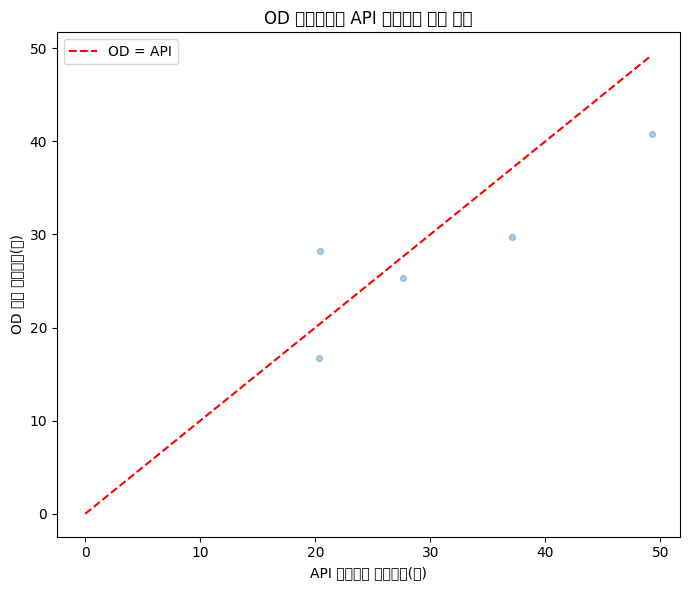

In [ ]:
def calculate_origin_metrics(origin_data):
    valid = origin_data.dropna(subset=[
        "OD 대표 통근시간(분)",
        "API 대표 통근시간(분)"
    ]).copy()

    if len(valid) < 2:
        return pd.DataFrame(columns=["지표", "값", "p값", "단위"])

    od_time = valid["OD 대표 통근시간(분)"]
    api_time = valid["API 대표 통근시간(분)"]
    weights = valid["비교 출근량"]
    difference = od_time - api_time
    spearman = spearmanr(od_time, api_time, nan_policy="omit")
    kendall = kendalltau(od_time, api_time, nan_policy="omit")

    return pd.DataFrame([
        {
            "지표": "행정동 Spearman 순위상관계수",
            "값": spearman.statistic,
            "p값": spearman.pvalue,
            "단위": "상관계수"
        },
        {
            "지표": "행정동 Kendall 순위상관계수",
            "값": kendall.statistic,
            "p값": kendall.pvalue,
            "단위": "상관계수"
        },
        {
            "지표": "행정동 MAE",
            "값": difference.abs().mean(),
            "p값": np.nan,
            "단위": "분"
        },
        {
            "지표": "행정동 통행량 가중 MAE",
            "값": np.average(difference.abs(), weights=weights),
            "p값": np.nan,
            "단위": "분"
        }
    ])


origin_metrics_80 = calculate_origin_metrics(origin_comparison_80)
display(origin_metrics_80)

if not pair_comparison_80.empty:
    plt.figure(figsize=(7, 6))
    plt.scatter(
        pair_comparison_80["API 통근시간(분)"],
        pair_comparison_80["OD 평균 이동시간(분)"],
        alpha=0.35,
        s=18
    )
    maximum = max(
        pair_comparison_80["API 통근시간(분)"].max(),
        pair_comparison_80["OD 평균 이동시간(분)"].max()
    )
    plt.plot([0, maximum], [0, maximum], "r--", label="OD = API")
    plt.xlabel("API 대중교통 통근시간(분)")
    plt.ylabel("OD 평균 이동시간(분)")
    plt.title("OD 이동시간과 API 대중교통 시간 비교")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 16. 누적 70%·80%·90% 민감도 검증

목적지 선정 기준을 바꿔도 상관관계와 오차의 방향이 유지되는지 확인한다.

In [ ]:
def metric_value(metric_table, metric_name):
    row = metric_table[metric_table["지표"] == metric_name]
    return row["값"].iloc[0] if not row.empty else np.nan


def metric_pvalue(metric_table, metric_name):
    row = metric_table[metric_table["지표"] == metric_name]
    return row["p값"].iloc[0] if not row.empty else np.nan


def run_sensitivity(od_data, api_routes, thresholds):
    rows = []

    for threshold in thresholds:
        selected = select_destinations(od_data, threshold)
        pair_data, coverage, merged = prepare_pair_comparison(
            selected,
            api_routes
        )
        metrics = calculate_pair_metrics(pair_data)

        rows.append({
            "누적 목적지 기준": threshold,
            "선택 외부 OD 수": int((
                selected["출발 행정동 코드"]
                != selected["도착 행정동 코드"]
            ).sum()),
            "API 성공 OD 수": len(pair_data),
            "API 외부경로 포함률": coverage,
            "Spearman 상관계수": metric_value(
                metrics, "Spearman 순위상관계수"
            ),
            "Spearman p값": metric_pvalue(
                metrics, "Spearman 순위상관계수"
            ),
            "통행량 가중 MAE(분)": metric_value(
                metrics, "통행량 가중 MAE"
            ),
            "통행량 가중 편향(분)": metric_value(
                metrics, "통행량 가중 편향"
            )
        })

    return pd.DataFrame(rows)


sensitivity_result = run_sensitivity(
    commute_od,
    route_cache_for_analysis,
    SENSITIVITY_THRESHOLDS
)
display(sensitivity_result)

,누적 목적지 기준,선택 외부 OD 수,API 성공 OD 수,API 외부경로 포함률,Spearman 상관계수,Spearman p값,통행량 가중 MAE(분),통행량 가중 편향(분)
0,0.700,17952,5,0.001,0.900,0.037,4.456,-3.002
1,0.800,28725,5,0.001,0.900,0.037,4.456,-3.002
2,0.900,50084,5,0.000,0.900,0.037,4.456,-3.002


## 17. 불일치 OD 확인

차이가 큰 경로를 자동으로 삭제하지 않는다.
중앙값 절대편차(MAD)를 이용해 확인 대상을 표시하고 이동량이 큰 순서도 함께 살펴본다.

In [ ]:
def find_disagreement_routes(pair_data):
    result = pair_data.copy()
    if result.empty:
        result["불일치 확인 대상"] = pd.Series(dtype=bool)
        return result

    difference = result["시간 차이(분)"]
    median_difference = difference.median()
    mad = (difference - median_difference).abs().median()

    if mad > 0:
        robust_limit = 3 * 1.4826 * mad
        result["불일치 확인 대상"] = (
            (difference - median_difference).abs() > robust_limit
        )
    else:
        result["불일치 확인 대상"] = False

    return result.sort_values(
        ["불일치 확인 대상", "절대 시간 차이(분)", "이동 인구수"],
        ascending=[False, False, False]
    )


disagreement_result = find_disagreement_routes(pair_comparison_80)

print(
    "불일치 확인 대상 OD:",
    int(disagreement_result["불일치 확인 대상"].sum())
    if not disagreement_result.empty else 0
)
display(disagreement_result.head(30))

불일치 확인 대상 OD: 0


,출발 행정동 코드,도착 행정동 코드,이동 인구수,OD 평균 이동시간(분),OD 평균 이동거리(m),목적지 이동비중,누적 목적지 비중,이전 누적비중,선택 기준,API 통근시간(분),API 이동거리(m),API 경로유형,API 환승횟수,API 요금(원),API 조회 성공,API 상태,API 오류,API 조회시각,API 성공 후 재조정 가중치,시간 차이(분),절대 시간 차이(분),불일치 확인 대상
4,11110515,11560540,20404.770,40.786,7395.349,0.024,0.407,0.383,0.800,49.250,10069.000,BUS,1.000,1500.000,True,OK,<NA>,2026-08-02T14:47:48,0.081,-8.464,8.464,False
3,11110515,11140520,23399.420,28.256,2118.882,0.028,0.383,0.355,0.800,20.433,3120.000,BUS,0.000,1500.000,True,OK,<NA>,2026-08-02T14:47:46,0.093,7.823,7.823,False
2,11110515,11140550,30883.930,29.712,2216.816,0.036,0.355,0.319,0.800,37.133,5074.000,BUS,0.000,1400.000,True,OK,<NA>,2026-08-02T14:47:45,0.123,-7.422,7.422,False
0,11110515,11110530,98963.430,16.724,867.719,0.116,0.116,0.000,0.800,20.367,1754.000,BUS,0.000,1500.000,True,OK,<NA>,2026-08-02T14:47:42,0.393,-3.643,3.643,False
1,11110515,11110615,78199.850,25.340,1734.285,0.092,0.319,0.227,0.800,27.600,3618.000,BUS,0.000,1400.000,True,OK,<NA>,2026-08-02T14:47:44,0.310,-2.260,2.260,False


## 18. 일일 무료 API 수집 결과 검증

하루에 무료 범위에서 수집한 경로만 별도로 비교한다.
일일 결과는 최종 결론이 아니라 누적 검증을 만들기 위한 중간 결과다.


In [ ]:
def get_daily_api_rows(route_cache, run_date):
    """API 호출 이력에서 지정한 날짜의 행만 가져온다."""
    if route_cache.empty:
        return route_cache.copy()

    result = route_cache.copy()
    timestamps = pd.to_datetime(
        result["API 조회시각"],
        errors="coerce"
    )
    result = result[
        timestamps.dt.strftime("%Y-%m-%d").eq(run_date)
    ].copy()
    return result.reset_index(drop=True)


def summarize_daily_api_calls(daily_rows):
    """하루 API 호출의 성공, 경로 없음, 오류 건수를 센다."""
    total_count = len(daily_rows)

    if total_count == 0:
        return {
            "당일 호출 건수": 0,
            "당일 성공 건수": 0,
            "당일 검색결과 없음 건수": 0,
            "당일 오류 건수": 0,
            "당일 호출 성공률": np.nan,
        }

    success = normalize_boolean(daily_rows["API 조회 성공"])
    status = daily_rows["API 상태"].astype("string")
    no_results = status.isin(["NO_RESULTS", "EQUAL_POINTS"])
    error_rows = ~success & ~no_results

    success_count = int(success.sum())
    return {
        "당일 호출 건수": int(total_count),
        "당일 성공 건수": success_count,
        "당일 검색결과 없음 건수": int(no_results.sum()),
        "당일 오류 건수": int(error_rows.sum()),
        "당일 호출 성공률": success_count / total_count,
    }


def make_daily_pair_comparison(selected_od, daily_rows):
    """당일 성공 경로와 같은 OD의 원본 이동시간을 결합한다."""
    if daily_rows.empty:
        return pd.DataFrame()

    success = normalize_boolean(daily_rows["API 조회 성공"])
    successful_routes = daily_rows[
        success & daily_rows["API 통근시간(분)"].notna()
    ].copy()

    if successful_routes.empty:
        return pd.DataFrame()

    successful_routes["정렬용 조회시각"] = pd.to_datetime(
        successful_routes["API 조회시각"],
        errors="coerce"
    )
    successful_routes = (
        successful_routes.sort_values("정렬용 조회시각")
        .drop_duplicates(
            subset=["출발 행정동 코드", "도착 행정동 코드"],
            keep="last"
        )
        .drop(columns="정렬용 조회시각")
    )

    external_od = selected_od[
        selected_od["출발 행정동 코드"]
        != selected_od["도착 행정동 코드"]
    ].copy()

    result = external_od.merge(
        successful_routes,
        on=["출발 행정동 코드", "도착 행정동 코드"],
        how="inner"
    )
    result["시간 차이(분)"] = (
        result["API 통근시간(분)"]
        - result["OD 평균 이동시간(분)"]
    )
    result["절대 시간 차이(분)"] = result["시간 차이(분)"].abs()
    return result


def calculate_daily_validation_metrics(pair_data):
    """당일 OD 시간과 API 시간의 차이를 간단한 지표로 계산한다."""
    if pair_data.empty:
        return {
            "비교 가능 OD 수": 0,
            "Spearman 순위상관계수": np.nan,
            "MAE(분)": np.nan,
            "이동량 가중 MAE(분)": np.nan,
            "이동량 가중 편향(분)": np.nan,
            "불일치 확인 대상 OD 수": 0,
        }

    result = pair_data.copy()
    if "시간 차이(분)" not in result.columns:
        result["시간 차이(분)"] = (
            result["API 통근시간(분)"]
            - result["OD 평균 이동시간(분)"]
        )
    if "절대 시간 차이(분)" not in result.columns:
        result["절대 시간 차이(분)"] = result["시간 차이(분)"].abs()

    if len(result) >= 2:
        spearman = spearmanr(
            result["OD 평균 이동시간(분)"],
            result["API 통근시간(분)"],
            nan_policy="omit"
        ).statistic
    else:
        spearman = np.nan

    total_flow = result["이동 인구수"].sum()
    if total_flow > 0:
        weighted_mae = np.average(
            result["절대 시간 차이(분)"],
            weights=result["이동 인구수"]
        )
        weighted_bias = np.average(
            result["시간 차이(분)"],
            weights=result["이동 인구수"]
        )
    else:
        weighted_mae = np.nan
        weighted_bias = np.nan

    difference = result["시간 차이(분)"]
    median_difference = difference.median()
    mad = (difference - median_difference).abs().median()
    if mad > 0:
        robust_limit = 3 * 1.4826 * mad
        disagreement_count = int(
            ((difference - median_difference).abs() > robust_limit).sum()
        )
    else:
        disagreement_count = 0

    return {
        "비교 가능 OD 수": int(len(result)),
        "Spearman 순위상관계수": spearman,
        "MAE(분)": result["절대 시간 차이(분)"].mean(),
        "이동량 가중 MAE(분)": weighted_mae,
        "이동량 가중 편향(분)": weighted_bias,
        "불일치 확인 대상 OD 수": disagreement_count,
    }


def format_report_value(value, digits=3):
    """보고서에서 결측값과 숫자를 보기 쉽게 표시한다."""
    if pd.isna(value):
        return "계산 불가"
    return f"{value:.{digits}f}"


def save_daily_validation_outputs(
    selected_od,
    route_cache,
    run_date,
    result_dir,
    existing_sequential_batch=False
):
    """당일 비교 CSV, 요약 CSV, 중간보고서를 각각 저장한다."""
    daily_dir = Path(result_dir) / "일별 검증 결과"
    daily_dir.mkdir(parents=True, exist_ok=True)

    daily_rows = get_daily_api_rows(route_cache, run_date)
    call_summary = summarize_daily_api_calls(daily_rows)
    pair_data = make_daily_pair_comparison(selected_od, daily_rows)
    metrics = calculate_daily_validation_metrics(pair_data)

    collection_type = (
        "기존 부분 수집 중간 결과"
        if existing_sequential_batch
        else "출발동 층화 일일 중간 결과"
    )
    summary = {
        "검증일": run_date,
        "검증 구분": collection_type,
        **call_summary,
        **metrics,
        "해석 상태": "최종 판정이 아닌 부분 표본 중간 검증",
    }
    summary_df = pd.DataFrame([summary])

    comparison_file = daily_dir / f"{run_date}_OD_API_비교결과.csv"
    summary_file = daily_dir / (
        f"{run_date}_통근시간_외적타당성_검증요약.csv"
    )
    report_file = daily_dir / (
        f"{run_date}_통근시간_외적타당성_중간보고서.md"
    )

    pair_data.to_csv(
        comparison_file,
        index=False,
        encoding="utf-8-sig"
    )
    summary_df.to_csv(
        summary_file,
        index=False,
        encoding="utf-8-sig"
    )

    report_text = f"""# {run_date} 통근시간 외적 타당성 중간 검증

## 검증 범위

- 수집 구분: {collection_type}
- 당일 API 호출: {call_summary["당일 호출 건수"]:,}건
- 당일 성공: {call_summary["당일 성공 건수"]:,}건
- 당일 경로 없음: {call_summary["당일 검색결과 없음 건수"]:,}건
- 당일 오류: {call_summary["당일 오류 건수"]:,}건
- 비교 가능 OD: {metrics["비교 가능 OD 수"]:,}개

## 시간 비교 결과

- Spearman 순위상관계수: {format_report_value(metrics["Spearman 순위상관계수"])}
- MAE: {format_report_value(metrics["MAE(분)"], 2)}분
- 이동량 가중 MAE: {format_report_value(metrics["이동량 가중 MAE(분)"], 2)}분
- 이동량 가중 편향: {format_report_value(metrics["이동량 가중 편향(분)"], 2)}분
- 불일치 확인 대상: {metrics["불일치 확인 대상 OD 수"]:,}개

## 해석

이 결과는 하루 무료 API 호출 범위에서 확보한 부분 표본을 이용한 중간 검증이다.
최종 판정이 아닌 결과이며, 날짜별 성공 경로를 누적한 뒤 전체 외적 타당성을 다시 판단한다.
API 시간은 주민센터 대표 좌표 사이의 대중교통 경로시간이므로 개인별 실제 통근시간과 동일하다고 해석하지 않는다.
"""
    report_file.write_text(report_text, encoding="utf-8")

    return {
        "비교결과": comparison_file,
        "검증요약": summary_file,
        "중간보고서": report_file,
    }


## 18. 결과 저장과 최종 해석

결과가 없을 때 긍정적인 결론을 만들지 않는다.
다음 조건을 함께 확인하여 `외적 타당성 근거 확인`, `제한적으로 확인`, `판정 보류`로 기록한다.

- 80% 기준 API 외부경로 포함률
- Spearman 순위상관의 방향과 p값
- API 장시간 집단과 단시간 집단의 차이
- 70%·80%·90% 민감도 결과의 방향

In [ ]:
def make_validation_summary(
    pair_metrics,
    origin_metrics,
    sensitivity,
    coverage,
    pair_count
):
    if pair_count < 2 or pair_metrics.empty:
        conclusion = "판정 보류"
        reason = "비교 가능한 API 경로가 부족합니다."
    elif pd.isna(coverage) or coverage < 0.80:
        conclusion = "판정 보류"
        reason = (
            "80% 기준 API 외부경로 포함률이 80% 미만이므로 "
            "시험·미완료 조회 결과로 최종 타당성을 판정하지 않습니다."
        )
    else:
        rho = metric_value(pair_metrics, "Spearman 순위상관계수")
        rho_p = metric_pvalue(pair_metrics, "Spearman 순위상관계수")
        u_p = metric_pvalue(pair_metrics, "Mann-Whitney U")

        stable_positive = (
            not sensitivity.empty
            and sensitivity["Spearman 상관계수"].notna().all()
            and sensitivity["Spearman 상관계수"].gt(0).all()
        )

        if (
            coverage >= 0.80
            and pd.notna(rho) and rho > 0
            and pd.notna(rho_p) and rho_p < 0.05
            and pd.notna(u_p) and u_p < 0.05
            and stable_positive
        ):
            conclusion = "외적 타당성 근거 확인"
            reason = (
                "API 포함률, 순위상관, 장·단시간 집단 차이와 "
                "70·80·90% 민감도 결과가 같은 방향을 보였습니다."
            )
        else:
            conclusion = "제한적으로 확인"
            reason = (
                "일부 외적 타당성 근거는 확인되었지만 포함률, 통계적 "
                "유의성 또는 민감도 중 보완이 필요한 항목이 있습니다."
            )

    return pd.DataFrame([{
        "검증 대상": "2025년 서울 출근 목적 OD 통근시간",
        "비교 가능 OD 수": pair_count,
        "80% 기준 API 외부경로 포함률": coverage,
        "최종 판정": conclusion,
        "판정 근거": reason
    }])


validation_summary = make_validation_summary(
    pair_metrics_80,
    origin_metrics_80,
    sensitivity_result,
    coverage_80,
    len(pair_comparison_80)
)
display(validation_summary)

# 오늘 수집한 결과는 일별 폴더에 별도로 저장한다.
VALIDATION_RUN_DATE = datetime.now().date().isoformat()
EXISTING_SEQUENTIAL_BATCH_DATE = "2026-08-02"

daily_output_paths = save_daily_validation_outputs(
    selected_80,
    route_cache,
    VALIDATION_RUN_DATE,
    RESULT_DIR,
    existing_sequential_batch=(
        VALIDATION_RUN_DATE == EXISTING_SEQUENTIAL_BATCH_DATE
    )
)

print("일일 검증 결과:")
for output_name, output_path in daily_output_paths.items():
    print(f"- {output_name}: {output_path}")


# 계산 결과 저장
pair_comparison_80.to_csv(
    RESULT_DIR / "OD_API_외적타당성_비교결과.csv",
    index=False,
    encoding="utf-8-sig"
)
origin_comparison_80.to_csv(
    RESULT_DIR / "행정동별_OD_API_대표통근시간.csv",
    index=False,
    encoding="utf-8-sig"
)
project_time_80.to_csv(
    RESULT_DIR / "행정동별_최종대표편도통근시간.csv",
    index=False,
    encoding="utf-8-sig"
)
sensitivity_result.to_csv(
    RESULT_DIR / "누적비중별_민감도검증.csv",
    index=False,
    encoding="utf-8-sig"
)
disagreement_result.to_csv(
    RESULT_DIR / "OD_API_불일치대상.csv",
    index=False,
    encoding="utf-8-sig"
)
validation_summary.to_csv(
    RESULT_DIR / "통근시간_외적타당성_검증요약.csv",
    index=False,
    encoding="utf-8-sig"
)

summary_row = validation_summary.iloc[0]
report_text = f"""# 통근시간 외적 타당성 검증 결과

## 검증 대상

{summary_row['검증 대상']}

## 주요 결과

- 비교 가능 OD 수: {int(summary_row['비교 가능 OD 수']):,}개
- 80% 기준 API 외부경로 포함률: {summary_row['80% 기준 API 외부경로 포함률']:.2%}
- 최종 판정: {summary_row['최종 판정']}

## 판정 근거

{summary_row['판정 근거']}

## 해석 범위

OD 평균 이동시간은 생활이동 자료의 관측 평균이고 API 시간은 행정동 주민센터
대표 좌표 사이의 대중교통 경로시간이다. 두 값이 완전히 동일하다는 의미가 아니라,
동일 OD의 상대적 장·단시간 순서와 주요 통행경로의 시간 수준이 일관되는지를 검증한 결과다.
"""

report_file = RESULT_DIR / "통근시간_외적타당성_검증결과.md"
report_file.write_text(report_text, encoding="utf-8")

print("결과 저장 완료:", RESULT_DIR)

,검증 대상,비교 가능 OD 수,80% 기준 API 외부경로 포함률,최종 판정,판정 근거
0,2025년 서울 출근 목적 OD 통근시간,5,0.001,판정 보류,80% 기준 API 외부경로 포함률이 80% 미만이므로 시험·미완료 조회 결과로 최...


결과 저장 완료: C:\Users\Owner\OneDrive\바탕 화면\데이터 분석\MULTICAM_11\프로젝트 전처리\통근 시간 외적 타당도 검증


## 19. 결과 해석 시 주의사항

- OD 평균시간은 실제 생활이동 자료의 집계값이다.
- API 시간은 주민센터 대표 좌표 사이의 대중교통 대표 경로시간이다.
- 따라서 두 시간이 완전히 같다는 것을 검증하는 분석이 아니다.
- 순위상관은 장거리·단거리 통근지역의 상대적 순서가 같은지 보여준다.
- 가중 MAE와 편향은 통행량이 많은 주요 OD에서 시간 수준이 얼마나 다른지 보여준다.
- API 실패는 이동이 없다는 의미가 아니므로 0으로 처리하지 않는다.
- 내부 통근은 외적 비교에서 제외하고 원본 OD 내부 평균시간으로 별도 처리한다.